# Multi-Output Regression for Java Ash HYSPLIT

Notebook ini membangun model multi-regressor untuk memprediksi target:
- `jarak_km`
- `luas_km2`
- `sudut_deg`
- `radius_km`

Rancangan eksekusi disusun agar stabil pada perangkat RAM terbatas tanpa mengubah setting model utama:
1. EDA ringkas dan validasi struktur data.
2. Preprocessing fitur numerik dan kategorikal.
3. Komparasi model dengan **full data** dan **setting sama**, dieksekusi **satu model per tahap**.
4. Checkpoint ke disk per-fold dan per-kandidat model.
5. Ringkasan metrik komparasi, pemilihan model terbaik, dan simpan artifact final kompatibel dengan app.

In [12]:
import gc
import json
import math
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import pydeck as pdk
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

DATA_PATH = Path("java-ash-hysplit.csv")
OUTPUT_DIR = Path("outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
MODEL_PATH = Path("best_multioutput_model.pkl")
MODEL_ARCHIVE_PATH = OUTPUT_DIR / "best_multioutput_model.pkl"
RUNS_PATH = OUTPUT_DIR / "model_runs.csv"
FOLD_RUNS_PATH = OUTPUT_DIR / "fold_runs.csv"
META_PATH = OUTPUT_DIR / "run_metadata.json"
SPLIT_PATH = OUTPUT_DIR / "splits.pkl"

TARGET_COLUMNS = ["jarak_km", "luas_km2", "sudut_deg", "radius_km"]
RANDOM_STATE = 42

EARTH_RADIUS_KM = 6371.0
SECTOR_SPREAD_DEG = 35.0
SECTOR_STEPS = 32
MAP_PROVIDER = "carto"
MAP_STYLE = "light"

LEVEL_SPECS = [
    (1, "Sangat Rendah", 1.00, [46, 139, 87, 90]),
    (2, "Rendah", 0.85, [154, 205, 50, 95]),
    (3, "Sedang", 0.65, [255, 215, 0, 105]),
    (4, "Tinggi", 0.45, [255, 140, 0, 120]),
    (5, "Sangat Tinggi", 0.25, [178, 34, 34, 130]),
]

In [13]:
df = pd.read_csv(DATA_PATH)

if "id" in df.columns:
    df = df.drop(columns=["id"])

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))

df.head()

Dataset shape: (1707, 15)

Columns:
['timestamp', 'volcano_filter', 'alert_level', 'latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'jarak_km', 'luas_km2', 'sudut_deg', 'radius_km']

Missing values (top 10):
timestamp           0
volcano_filter      0
alert_level         0
latitude            0
longitude           0
elevation           0
tinggi_letusan_m    0
kec_angin_km_jam    0
arah_angin_deg      0
amplitudo           0
dtype: int64


,timestamp,volcano_filter,alert_level,latitude,longitude,elevation,tinggi_letusan_m,kec_angin_km_jam,arah_angin_deg,amplitudo,duration,jarak_km,luas_km2,sudut_deg,radius_km
0,2024-06-11 07:34:00 UTC,Merapi,Yellow,-7.54194,110.44194,2968,1000.0,4.7,270.0,50.0,30.0,32.511505,614.390650,303.257335,18.304149
1,2024-01-24 08:56:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1000.0,8.0,135.0,51.0,168.0,27.761756,460.792988,37.901873,15.892819
2,2023-03-15 03:36:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1200.0,7.1,90.0,65.0,133.0,44.625714,614.214150,265.635506,23.934437
3,2023-03-13 22:50:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,1500.0,3.2,135.0,70.0,160.0,22.998759,184.285530,288.108280,11.770659
4,2023-03-12 09:19:00 UTC,Merapi,Orange,-7.54194,110.44194,2968,2500.0,8.3,315.0,70.0,145.0,39.159595,307.107075,270.462663,20.809694


In [14]:
required_targets = set(TARGET_COLUMNS)
missing_targets = sorted(required_targets.difference(df.columns))
if missing_targets:
    raise ValueError(f"Target column tidak ditemukan: {missing_targets}")

duplicate_rows = int(df.duplicated().sum())
print(f"Jumlah baris duplikat: {duplicate_rows}")

if "timestamp" in df.columns:
    timestamp_parsed = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["year"] = timestamp_parsed.dt.year
    df["month"] = timestamp_parsed.dt.month
    df["day"] = timestamp_parsed.dt.day
    df["hour"] = timestamp_parsed.dt.hour
    df["day_of_week"] = timestamp_parsed.dt.dayofweek
    hour_angle = 2 * math.pi * (df["hour"].fillna(0) / 24.0)
    df["hour_sin"] = hour_angle.apply(math.sin)
    df["hour_cos"] = hour_angle.apply(math.cos)
    df = df.drop(columns=["timestamp"])

for target_col in TARGET_COLUMNS:
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

constant_cols = [
    col for col in df.columns
    if col not in TARGET_COLUMNS and df[col].nunique(dropna=False) <= 1
]
if constant_cols:
    print(f"Kolom konstan dihapus: {constant_cols}")
    df = df.drop(columns=constant_cols)

candidate_features = [col for col in df.columns if col not in TARGET_COLUMNS]
numeric_feature_columns = [
    col for col in candidate_features
    if pd.api.types.is_numeric_dtype(df[col])
]
categorical_feature_columns = [
    col for col in candidate_features
    if col not in numeric_feature_columns
]

if not candidate_features:
    raise ValueError("Tidak ada fitur yang bisa digunakan setelah preprocessing.")

X = df[candidate_features].copy()
y = df[TARGET_COLUMNS].copy()

valid_target_mask = y.notna().all(axis=1)
X = X.loc[valid_target_mask]
y = y.loc[valid_target_mask]

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = pd.to_numeric(X[col], errors="coerce", downcast="float")
    else:
        X[col] = X[col].astype("category")

y = y.apply(pd.to_numeric, errors="coerce").astype("float32")

if len(X) < 100:
    raise ValueError(f"Data valid terlalu sedikit untuk training yang stabil: {len(X)} baris")

mem_x_mb = X.memory_usage(deep=True).sum() / (1024**2)
mem_y_mb = y.memory_usage(deep=True).sum() / (1024**2)

print(f"Jumlah fitur kandidat: {len(candidate_features)}")
print(f"Fitur numerik: {len(numeric_feature_columns)} | Fitur kategorikal: {len(categorical_feature_columns)}")
print(f"Contoh fitur numerik: {numeric_feature_columns[:10]}")
print(f"Contoh fitur kategorikal: {categorical_feature_columns[:10]}")
print(f"Shape final X: {X.shape}")
print(f"Shape final y: {y.shape}")
print(f"Estimasi memori X: {mem_x_mb:.2f} MB | y: {mem_y_mb:.2f} MB")

Jumlah baris duplikat: 0
Jumlah fitur kandidat: 17
Fitur numerik: 15 | Fitur kategorikal: 2
Contoh fitur numerik: ['latitude', 'longitude', 'elevation', 'tinggi_letusan_m', 'kec_angin_km_jam', 'arah_angin_deg', 'amplitudo', 'duration', 'year', 'month']
Contoh fitur kategorikal: ['volcano_filter', 'alert_level']
Shape final X: (1707, 17)
Shape final y: (1707, 4)
Estimasi memori X: 0.11 MB | y: 0.04 MB


In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

for stale_path in [RUNS_PATH, FOLD_RUNS_PATH, META_PATH, SPLIT_PATH]:
    if stale_path.exists():
        stale_path.unlink()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

numeric_features = [
    col for col in X_train.columns if pd.api.types.is_numeric_dtype(X_train[col])
]
categorical_features = [col for col in X_train.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(handle_unknown="ignore", sparse_output=True),
                ),
            ]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=600,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_base = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

et_base = ExtraTreesRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lin_base = LinearRegression()

candidate_models = {
    "xgboost": Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("regressor", MultiOutputRegressor(xgb_base)),
        ]
    ),
    # "random_forest": Pipeline(
    #     steps=[
    #         ("preprocessor", clone(preprocessor)),
    #         ("regressor", MultiOutputRegressor(rf_base)),
    #     ]
    # ),
    # "extra_trees": Pipeline(
    #     steps=[
    #         ("preprocessor", clone(preprocessor)),
    #         ("regressor", MultiOutputRegressor(et_base)),
    #     ]
    # ),
    # "linear_baseline": Pipeline(
    #     steps=[
    #         ("preprocessor", clone(preprocessor)),
    #         ("regressor", MultiOutputRegressor(lin_base)),
    #     ]
    # ),
}

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_indices = list(kf.split(X_train, y_train))

joblib.dump(
    {
        "x_train_index": X_train.index.to_numpy(),
        "x_test_index": X_test.index.to_numpy(),
        "fold_indices": cv_indices,
    },
    SPLIT_PATH,
    compress=3,
)

comparison_rows = []
fold_rows = []

for model_name, model_pipeline in candidate_models.items():
    model_start = time.time()
    print(f"\nTraining model: {model_name}")

    cv_r2_values = []
    cv_mae_values = []
    cv_rmse_values = []

    for fold_num, (tr_idx, val_idx) in enumerate(cv_indices, start=1):
        fold_start = time.time()
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        fold_model = clone(model_pipeline)
        fold_model.fit(X_tr, y_tr)
        y_val_pred = fold_model.predict(X_val)

        fold_r2 = r2_score(y_val, y_val_pred)
        fold_mae = mean_absolute_error(y_val, y_val_pred)
        fold_rmse = mean_squared_error(y_val, y_val_pred) ** 0.5
        fold_elapsed = time.time() - fold_start

        cv_r2_values.append(fold_r2)
        cv_mae_values.append(fold_mae)
        cv_rmse_values.append(fold_rmse)

        fold_row = {
            "model": model_name,
            "fold": fold_num,
            "cv_r2": fold_r2,
            "cv_mae": fold_mae,
            "cv_rmse": fold_rmse,
            "elapsed_seconds": fold_elapsed,
        }
        fold_rows.append(fold_row)

        fold_ckpt_path = CHECKPOINT_DIR / f"{model_name}_fold_{fold_num}.pkl"
        joblib.dump(
            {
                "model_name": model_name,
                "fold": fold_num,
                "model": fold_model,
            },
            fold_ckpt_path,
            compress=3,
        )

        pd.DataFrame(fold_rows).to_csv(FOLD_RUNS_PATH, index=False)

        del fold_model, X_tr, y_tr, X_val, y_val, y_val_pred
        gc.collect()

    holdout_model = clone(model_pipeline)
    holdout_model.fit(X_train, y_train)
    holdout_pred = holdout_model.predict(X_test)

    candidate_ckpt_path = CHECKPOINT_DIR / f"{model_name}_candidate.pkl"
    joblib.dump(
        {
            "model_name": model_name,
            "model": holdout_model,
        },
        candidate_ckpt_path,
        compress=3,
    )

    comparison_rows.append(
        {
            "model": model_name,
            "cv_r2_mean": float(pd.Series(cv_r2_values).mean()),
            "cv_r2_std": float(pd.Series(cv_r2_values).std(ddof=0)),
            "cv_mae_mean": float(pd.Series(cv_mae_values).mean()),
            "cv_rmse_mean": float(pd.Series(cv_rmse_values).mean()),
            "holdout_r2": r2_score(y_test, holdout_pred),
            "holdout_mae": mean_absolute_error(y_test, holdout_pred),
            "holdout_rmse": mean_squared_error(y_test, holdout_pred) ** 0.5,
            "elapsed_seconds": time.time() - model_start,
            "candidate_checkpoint": str(candidate_ckpt_path),
        }
    )

    pd.DataFrame(comparison_rows).to_csv(RUNS_PATH, index=False)
    print(f"Selesai model: {model_name}")

    del holdout_model, holdout_pred
    gc.collect()

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=["cv_r2_mean", "holdout_r2"],
    ascending=False,
).reset_index(drop=True)

best_model_name = comparison_df.iloc[0]["model"]
best_bundle = joblib.load(CHECKPOINT_DIR / f"{best_model_name}_candidate.pkl")
best_model = best_bundle["model"]

transformed_feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
feature_columns = transformed_feature_names.tolist()

run_metadata = {
    "random_state": RANDOM_STATE,
    "n_splits": 10,
    "settings_locked": True,
    "target_columns": TARGET_COLUMNS,
    "output_files": {
        "model_runs": str(RUNS_PATH),
        "fold_runs": str(FOLD_RUNS_PATH),
        "splits": str(SPLIT_PATH),
        "best_model": str(MODEL_PATH),
    },
}

with META_PATH.open("w", encoding="utf-8") as f:
    json.dump(run_metadata, f, ensure_ascii=False, indent=2)

comparison_df


Training model: xgboost
Selesai model: xgboost


,model,cv_r2_mean,cv_r2_std,cv_mae_mean,cv_rmse_mean,holdout_r2,holdout_mae,holdout_rmse,elapsed_seconds,candidate_checkpoint
0,xgboost,0.710163,0.176067,33.672105,147.42599,0.837026,30.45298,97.575336,19.704657,outputs\checkpoints\xgboost_candidate.pkl


In [16]:
y_pred = best_model.predict(X_test)

holdout_metrics = []
for idx, target_name in enumerate(TARGET_COLUMNS):
    target_true = y_test.iloc[:, idx]
    target_pred = y_pred[:, idx]

    mse_value = mean_squared_error(target_true, target_pred)

    holdout_metrics.append(
        {
            "target": target_name,
            "mae": mean_absolute_error(target_true, target_pred),
            "rmse": mse_value ** 0.5,
            "r2": r2_score(target_true, target_pred),
        }
    )

holdout_metrics_df = pd.DataFrame(holdout_metrics)
print(f"Best model: {best_model_name}")
holdout_metrics_df

Best model: xgboost


,target,mae,rmse,r2
0,jarak_km,3.747096,9.344882,0.859937
1,luas_km2,95.470963,190.280991,0.798440
2,sudut_deg,20.532497,41.937308,0.852054
3,radius_km,2.061375,5.555483,0.837672


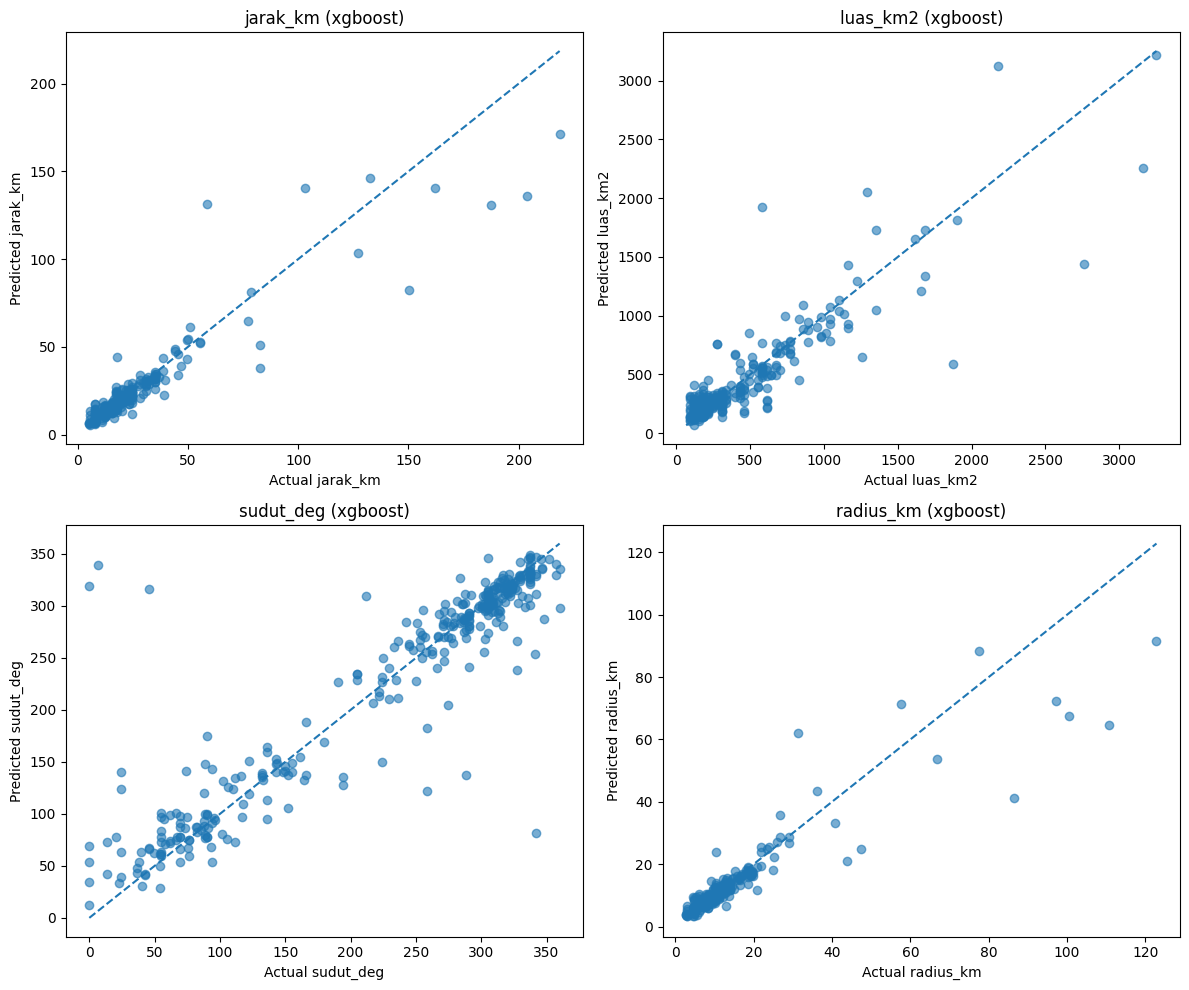

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, target_name in enumerate(TARGET_COLUMNS):
    actual = y_test.iloc[:, i]
    predicted = y_pred[:, i]

    min_v = min(actual.min(), predicted.min())
    max_v = max(actual.max(), predicted.max())

    axes[i].scatter(actual, predicted, alpha=0.6)
    axes[i].plot([min_v, max_v], [min_v, max_v], linestyle="--")
    axes[i].set_xlabel(f"Actual {target_name}")
    axes[i].set_ylabel(f"Predicted {target_name}")
    axes[i].set_title(f"{target_name} ({best_model_name})")

plt.tight_layout()
plt.show()

In [18]:
sample_input = X_test.iloc[[0]].copy()
sample_prediction = best_model.predict(sample_input)

sample_result = pd.DataFrame(sample_prediction, columns=TARGET_COLUMNS)
print("Contoh inferensi 1 baris input:")
display(sample_result)

Contoh inferensi 1 baris input:


,jarak_km,luas_km2,sudut_deg,radius_km
0,25.845198,348.662384,281.159393,13.780741


In [19]:
first_target_estimator = best_model.named_steps["regressor"].estimators_[0]

if hasattr(first_target_estimator, "feature_importances_"):
    feature_importance = pd.Series(
        first_target_estimator.feature_importances_,
        index=feature_columns,
    ).sort_values(ascending=False)

    print("Top 15 feature importance:")
    display(feature_importance.head(15).to_frame("importance"))
else:
    feature_importance = pd.Series(dtype=float)
    print("Model terbaik tidak menyediakan feature_importances_.")

Top 15 feature importance:


,importance
cat__volcano_filter_Semeru,0.179068
num__tinggi_letusan_m,0.177705
num__year,0.148784
num__elevation,0.116564
num__month,0.075921
cat__alert_level_Red,0.042176
num__hour,0.042099
num__day,0.040240
num__latitude,0.035785
cat__alert_level_Orange,0.034927


In [20]:
summary_df = pd.DataFrame(
    [
        {
            "best_model": best_model_name,
            "cv_r2_mean": comparison_df.iloc[0]["cv_r2_mean"],
            "holdout_r2": comparison_df.iloc[0]["holdout_r2"],
            "holdout_mae": comparison_df.iloc[0]["holdout_mae"],
            "holdout_rmse": comparison_df.iloc[0]["holdout_rmse"],
            "n_features": len(feature_columns),
            "n_train_rows": len(X_train),
            "n_test_rows": len(X_test),
            "runs_path": str(RUNS_PATH),
            "fold_runs_path": str(FOLD_RUNS_PATH),
        }
    ]
)

print("Ringkasan model terbaik:")
display(summary_df)
print("\nMetrik holdout per target:")
display(holdout_metrics_df)

Ringkasan model terbaik:


,best_model,cv_r2_mean,holdout_r2,holdout_mae,holdout_rmse,n_features,n_train_rows,n_test_rows,runs_path,fold_runs_path
0,xgboost,0.710163,0.837026,30.45298,97.575336,24,1365,342,outputs\model_runs.csv,outputs\fold_runs.csv



Metrik holdout per target:


,target,mae,rmse,r2
0,jarak_km,3.747096,9.344882,0.859937
1,luas_km2,95.470963,190.280991,0.798440
2,sudut_deg,20.532497,41.937308,0.852054
3,radius_km,2.061375,5.555483,0.837672


In [21]:
artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "feature_columns": feature_columns,
    "target_columns": TARGET_COLUMNS,
    "comparison": comparison_df,
    "holdout_metrics": holdout_metrics_df,
    "run_metadata": run_metadata,
}

MODEL_ARCHIVE_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, MODEL_PATH, compress=3)
joblib.dump(artifact, MODEL_ARCHIVE_PATH, compress=3)

print(f"Model terbaik tersimpan di: {MODEL_PATH.resolve()}")
print(f"Arsip model tersimpan di: {MODEL_ARCHIVE_PATH.resolve()}")

Model terbaik tersimpan di: E:\Challange\Try\best_multioutput_model.pkl
Arsip model tersimpan di: E:\Challange\Try\outputs\best_multioutput_model.pkl


In [22]:
def destination_point(lat: float, lon: float, distance_km: float, bearing_deg: float):
    lat1 = math.radians(lat)
    lon1 = math.radians(lon)
    bearing = math.radians(bearing_deg % 360)
    angular_distance = distance_km / EARTH_RADIUS_KM

    lat2 = math.asin(
        math.sin(lat1) * math.cos(angular_distance)
        + math.cos(lat1) * math.sin(angular_distance) * math.cos(bearing)
    )
    lon2 = lon1 + math.atan2(
        math.sin(bearing) * math.sin(angular_distance) * math.cos(lat1),
        math.cos(angular_distance) - math.sin(lat1) * math.sin(lat2),
    )

    return math.degrees(lat2), math.degrees(lon2)


def build_sector_polygon(origin_lat, origin_lon, radius_km, center_bearing_deg):
    start_bearing = center_bearing_deg - (SECTOR_SPREAD_DEG / 2)
    end_bearing = center_bearing_deg + (SECTOR_SPREAD_DEG / 2)

    points = [[origin_lon, origin_lat]]
    for i in range(SECTOR_STEPS + 1):
        t = i / SECTOR_STEPS
        bearing = start_bearing + t * (end_bearing - start_bearing)
        lat_pt, lon_pt = destination_point(origin_lat, origin_lon, radius_km, bearing)
        points.append([lon_pt, lat_pt])

    points.append([origin_lon, origin_lat])
    return points


reference_stats = {
    "radius_min": float(df["radius_km"].quantile(0.05)),
    "radius_max": float(df["radius_km"].quantile(0.95)),
    "area_min": float(df["luas_km2"].quantile(0.05)),
    "area_max": float(df["luas_km2"].quantile(0.95)),
}

if "sample_result" not in globals():
    sample_prediction = best_model.predict(sample_input)
    sample_result = pd.DataFrame(sample_prediction, columns=TARGET_COLUMNS)

origin_lat = float(sample_input.iloc[0]["latitude"])
origin_lon = float(sample_input.iloc[0]["longitude"])
radius_km = max(1.0, float(sample_result.iloc[0]["radius_km"]))
area_km2 = max(1.0, float(sample_result.iloc[0]["luas_km2"]))
center_bearing_deg = float(sample_result.iloc[0].get("sudut_deg", sample_input.iloc[0]["arah_angin_deg"]))

radius_norm = (radius_km - reference_stats["radius_min"]) / max(1e-6, (reference_stats["radius_max"] - reference_stats["radius_min"]))
area_norm = (area_km2 - reference_stats["area_min"]) / max(1e-6, (reference_stats["area_max"] - reference_stats["area_min"]))
base_severity = max(0.0, min(1.0, (0.6 * radius_norm) + (0.4 * area_norm)))

polygon_rows = []
summary_rows = []
for level, label, radius_factor, fill_color in LEVEL_SPECS:
    zone_radius = max(1.0, radius_km * radius_factor)
    proximity_weight = max(0.0, min(1.0, 1.15 - radius_factor))
    level_score = max(0.0, min(1.0, base_severity * (0.75 + 0.5 * proximity_weight)))

    polygon_rows.append(
        {
            "level": level,
            "label": label,
            "radius_km": round(zone_radius, 2),
            "impact_score": round(level_score, 3),
            "coordinates": build_sector_polygon(origin_lat, origin_lon, zone_radius, center_bearing_deg),
            "fill_color": fill_color,
        }
    )

    center_lat, center_lon = destination_point(origin_lat, origin_lon, zone_radius * 0.7, center_bearing_deg)
    summary_rows.append(
        {
            "level": level,
            "kategori": label,
            "radius_km": round(zone_radius, 2),
            "estimasi_luas_km2": round(area_km2 * (radius_factor**2), 2),
            "impact_score": round(level_score, 3),
            "pusat_lat": round(center_lat, 6),
            "pusat_lon": round(center_lon, 6),
        }
    )

polygon_df = pd.DataFrame(polygon_rows).sort_values("level")
summary_impact = pd.DataFrame(summary_rows).sort_values("level", ascending=False)

centerline_lat, centerline_lon = destination_point(origin_lat, origin_lon, radius_km, center_bearing_deg)
centerline_df = pd.DataFrame(
    [{"path": [[origin_lon, origin_lat], [centerline_lon, centerline_lat]]}]
)
points_df = pd.DataFrame(
    [
        {"name": "Pusat erupsi", "lat": origin_lat, "lon": origin_lon, "color": [20, 20, 20, 255], "radius": 550},
        {
            "name": "Arah dominan abu",
            "lat": centerline_lat,
            "lon": centerline_lon,
            "color": [178, 34, 34, 240],
            "radius": 420,
        },
    ]
)

map_layers = [
    pdk.Layer(
        "PolygonLayer",
        data=polygon_df,
        get_polygon="coordinates",
        get_fill_color="fill_color",
        get_line_color=[60, 60, 60, 140],
        line_width_min_pixels=1,
        pickable=True,
    ),
    pdk.Layer(
        "PathLayer",
        data=centerline_df,
        get_path="path",
        get_color=[180, 30, 30, 220],
        width_scale=1,
        width_min_pixels=2,
    ),
    pdk.Layer(
        "ScatterplotLayer",
        data=points_df,
        get_position="[lon, lat]",
        get_fill_color="color",
        get_radius="radius",
        pickable=True,
    ),
]

zoom = max(6.5, 10.7 - (math.log10(radius_km + 1.0) * 1.7))
deck = pdk.Deck(
    map_provider=MAP_PROVIDER,
    map_style=MAP_STYLE,
    initial_view_state=pdk.ViewState(
        latitude=origin_lat,
        longitude=origin_lon,
        zoom=zoom,
        pitch=35,
    ),
    layers=map_layers,
    tooltip={
        "html": "<b>Level:</b> {level} - {label}<br/><b>Radius:</b> {radius_km} km<br/><b>Skor:</b> {impact_score}",
        "style": {"backgroundColor": "#111111", "color": "#ffffff"},
    },
)

print("Peta sebaran abu berbasis prediksi (simulasi mendekati pola HYSPLIT):")
deck

print("Ringkasan titik/wilayah terdampak:")
display(summary_impact)

Peta sebaran abu berbasis prediksi (simulasi mendekati pola HYSPLIT):
Ringkasan titik/wilayah terdampak:


,level,kategori,radius_km,estimasi_luas_km2,impact_score,pusat_lat,pusat_lon
4,5,Sangat Tinggi,3.45,21.79,0.459,-8.103852,112.898505
3,4,Tinggi,6.20,70.60,0.420,-8.100493,112.881311
2,3,Sedang,8.96,147.31,0.382,-8.097133,112.864118
1,2,Rendah,11.71,251.91,0.344,-8.093772,112.846924
0,1,Sangat Rendah,13.78,348.66,0.315,-8.091251,112.834029
